# [LAB 04] 11. 이상치 처리 - 연습문제

## 준비작업

### 라이브러리 참조

In [1]:
import numpy as np
from hossam import load_data
from pandas import DataFrame
from sklearn.impute import SimpleImputer
from matplotlib import pyplot as plt

## 요구사항 해결

### 문제 1: 데이터 불러오기 및 기본 정보 확인

#### 1) plant_growth 데이터를 불러와 데이터프레임으로 만드세요.

In [2]:
df = load_data("plant_growth")
df

📚 신비한 식물의 성장 기록 데이터

    field           description
--  --------------  ----------------------------------------
 0  plant_id        식물의 고유 ID(인덱스)
 1  species         식물의 종 (GlowLeaf, SunPetal, AquaRoot)
 2  height_cm       식물의 키 (cm)
 3  sunlight_hours  일일 평균 햇빛 노출 시간
 4  water_ml        일일 평균 물 공급량 (ml)



,species,height_cm,sunlight_hours,water_ml
plant_id,,,,
1,GlowLeaf,15.200,5.100,505
2,GlowLeaf,14.800,4.900,498
3,GlowLeaf,15.500,5.200,510
4,GlowLeaf,110.000,5.000,502
5,GlowLeaf,15.100,4.800,495
6,SunPetal,25.300,8.200,705
7,SunPetal,24.900,8.100,698
8,SunPetal,25.500,8.300,710
9,SunPetal,25.100,8.000,702


#### 2) 데이터프레임의 기본적인 구조와 정보(처음 5개 행, 각 열의 데이터 타입 및 결측치 여부)를 확인하세요.

##### 처음 5개 행

In [3]:
df.head()

,species,height_cm,sunlight_hours,water_ml
plant_id,,,,
1,GlowLeaf,15.200,5.100,505
2,GlowLeaf,14.800,4.900,498
3,GlowLeaf,15.500,5.200,510
4,GlowLeaf,110.000,5.000,502
5,GlowLeaf,15.100,4.800,495


##### 각 열의 데이터 타입

In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 20 entries, 1 to 20
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   species         20 non-null     str    
 1   height_cm       20 non-null     float64
 2   sunlight_hours  20 non-null     float64
 3   water_ml        20 non-null     int64  
dtypes: float64(2), int64(1), str(1)
memory usage: 960.0 bytes


##### 결측치 여부

In [5]:
df.isna().sum()

species           0
height_cm         0
sunlight_hours    0
water_ml          0
dtype: int64

### 문제 2: 데이터 시각화를 통한 이상치 탐색

#### 1) 각 식물 종(`species`)별로 `height_cm`, `sunlight_hours`, `water_ml`에 대한 상자 그림(`boxplot`)을 그려보세요.

##### 식물 종의 종류를 확인하기 위해서 종류별로 집계

In [6]:
df['species'].value_counts()

species
GlowLeaf    7
SunPetal    7
AquaRoot    6
Name: count, dtype: int64

##### `GlowLeaf` 유형만 필터링 하여 상자그림 생성

In [7]:
df_glowleaf = df[df['species'] == 'GlowLeaf']
df_glowleaf

,species,height_cm,sunlight_hours,water_ml
plant_id,,,,
1,GlowLeaf,15.200,5.100,505
2,GlowLeaf,14.800,4.900,498
3,GlowLeaf,15.500,5.200,510
4,GlowLeaf,110.000,5.000,502
5,GlowLeaf,15.100,4.800,495
16,GlowLeaf,14.900,5.300,512
17,GlowLeaf,15.300,5.100,508


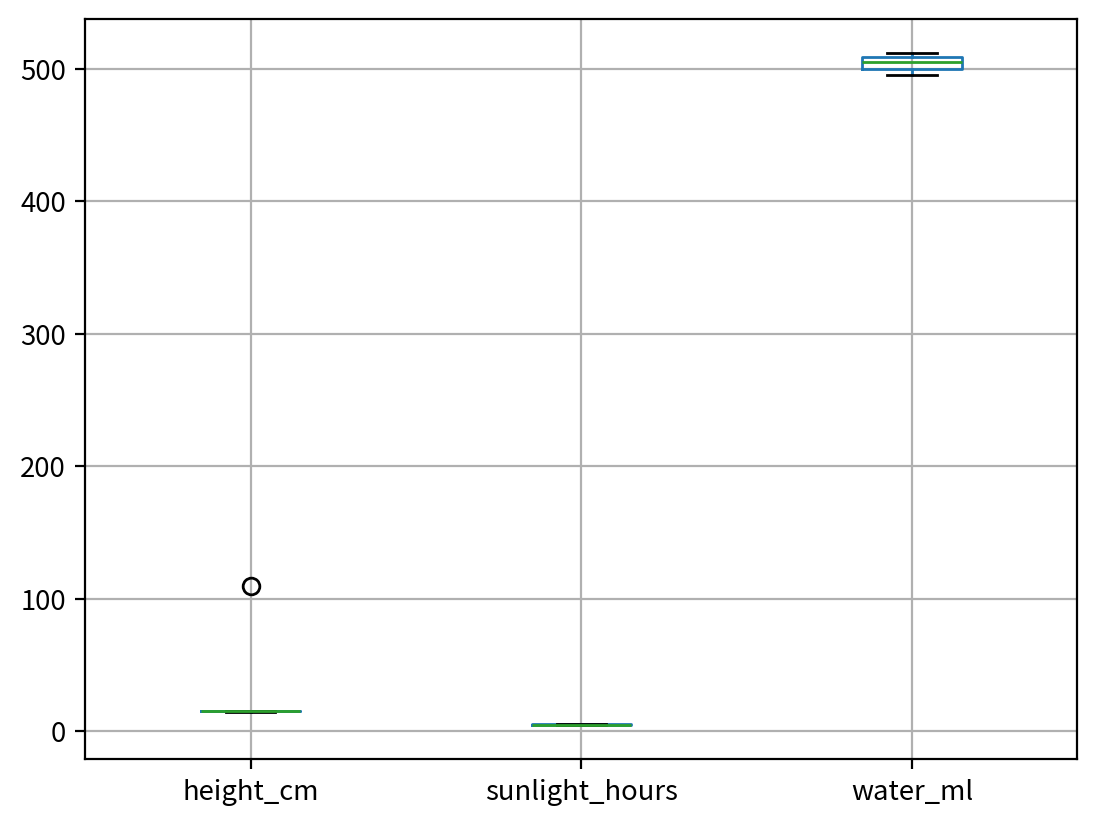

In [8]:
df_glowleaf.boxplot()
plt.show()

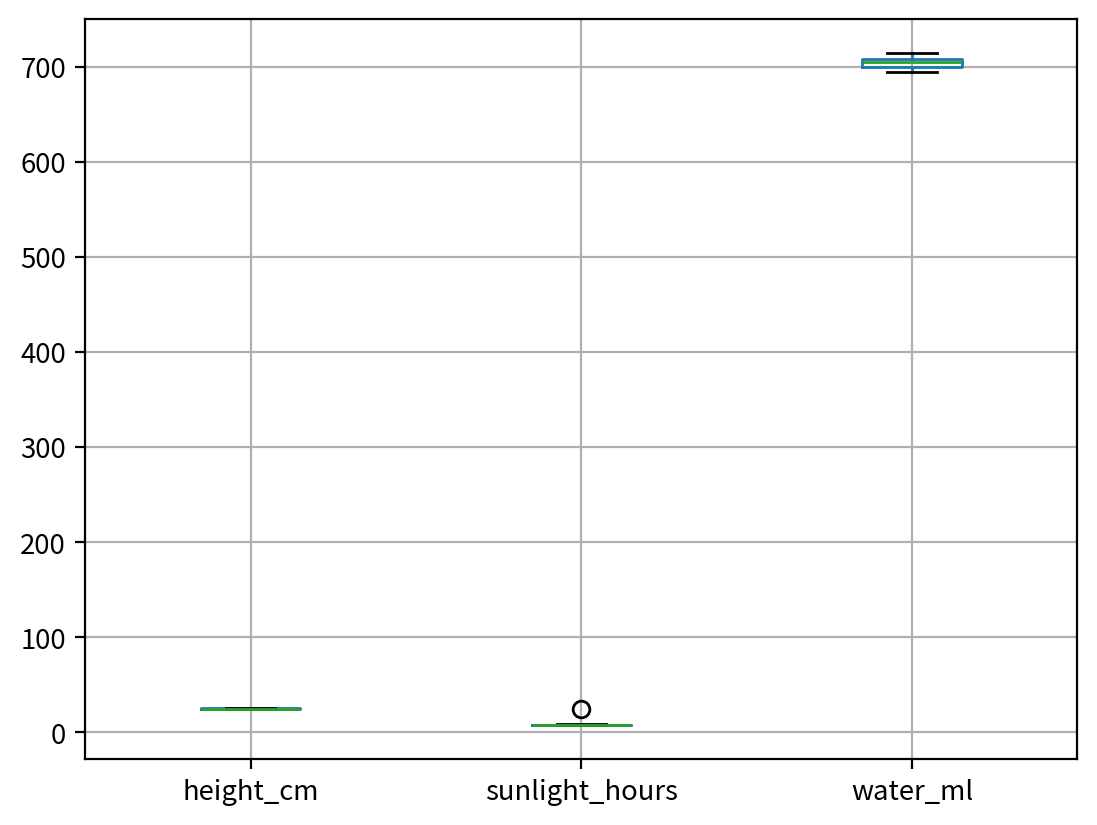

In [9]:
df[df['species'] == 'SunPetal'].boxplot()
plt.show()

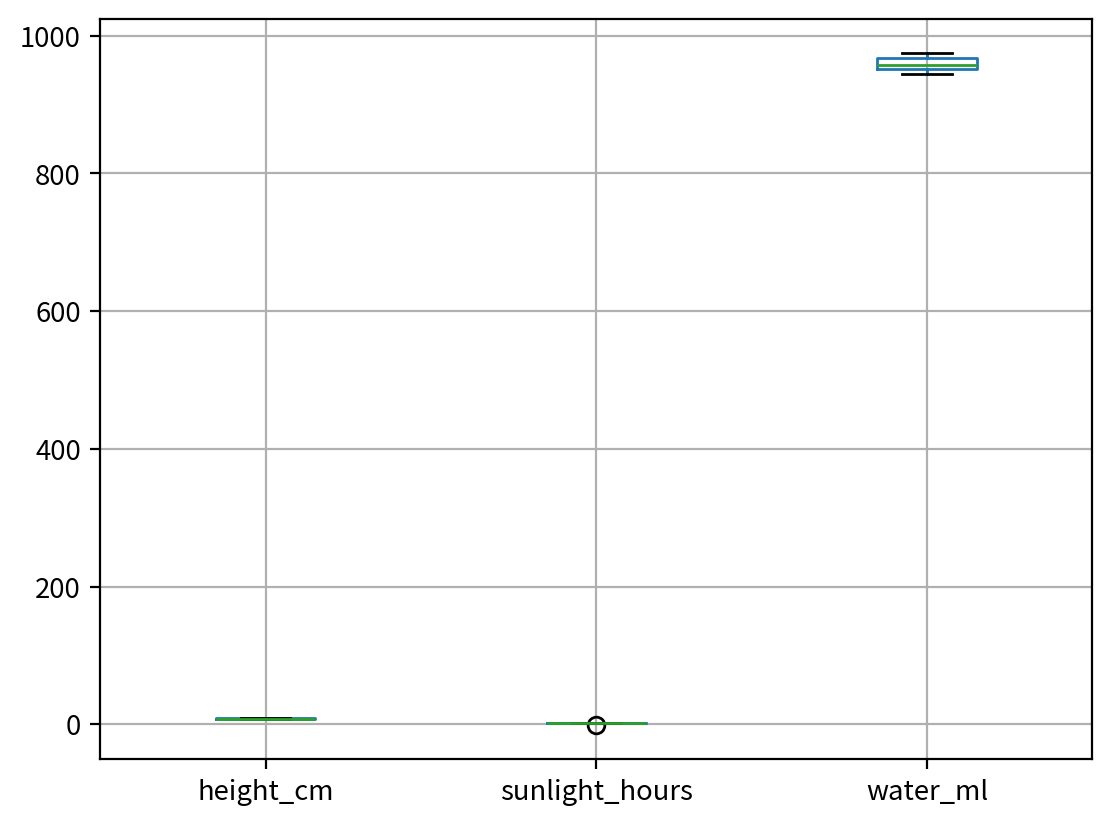

In [10]:
df[df['species'] == 'AquaRoot'].boxplot()
plt.show()

#### 2) 생성된 그래프를 보고 이상치로 의심되는 값들이 어떤 열과 종에 있는지 설명해보세요.


- `GlowLeaf`종 : 키에 이상치가 검출되었다.
- `SunPetal`종 : 평균 햇빛 노출 시간에서 이상치가 검출되었다.
- `AquaRoot`종 : 평균 햇빛 노출 시간에서 이상치가 검출되었다.

### 문제 3: IQR을 이용한 이상치 식별 및 정제

#### 1) 종에 대한 구별 없이 `height_cm`열에 대해 `IQR`을 계산하고, 이를 바탕으로 이상치의 경계(하한, 상한)를 구하세요. 출력할 때는 소수점 2째자리까지만 표시하세요. 종에 대한 구별 없는 데이터 셋을 위해서 종을 의미하는 변수를 제거하세요.

In [11]:
df2 = df.drop(columns='species')

height_cm_q1 = df2['height_cm'].quantile(0.25)
height_cm_q3 = df2['height_cm'].quantile(0.75)
height_cm_iqr = height_cm_q3 - height_cm_q1
outline_max = height_cm_q3 + height_cm_iqr * 1.5
outline_min = height_cm_q1 - height_cm_iqr * 1.5
print("height_cm에 대한 iqr: %.2f, 하한 이상치 경계: %.2f, 상한 이상치 경계: %.2f" % (height_cm_iqr, outline_min, outline_max))

height_cm에 대한 iqr: 16.45, 하한 이상치 경계: -16.10, 상한 이상치 경계: 49.70


#### 2) 위에서 구한 경계를 벗어나는 이상치를 식별하고, 어떤 값인지 출력하세요.

In [12]:
df2.loc[(df2['height_cm'] < outline_min) | (df2['height_cm'] > outline_max)]

,height_cm,sunlight_hours,water_ml
plant_id,,,
4,110.000,5.000,502


#### 3) `sunlight_hours`열에 대해서도 동일한 과정을 반복하여 이상치를 찾아내고, 해당 값을 출력하세요.

In [13]:
sunlight_hours_q1 = df2['sunlight_hours'].quantile(0.25)
sunlight_hours_q3 = df2['sunlight_hours'].quantile(0.75)
sunlight_hours_iqr = sunlight_hours_q3 - sunlight_hours_q1
outline_max = sunlight_hours_q3 + sunlight_hours_iqr * 1.5
outline_min = sunlight_hours_q1 - sunlight_hours_iqr * 1.5
print("sunlight_hours에 대한 iqr: %.2f, 하한 이상치 경계: %.2f, 상한 이상치 경계: %.2f" % (sunlight_hours_iqr, outline_min, outline_max))

df2.loc[(df2['sunlight_hours'] < outline_min) | (df2['sunlight_hours'] > outline_max)]

sunlight_hours에 대한 iqr: 5.65, 하한 이상치 경계: -6.10, 상한 이상치 경계: 16.50


,height_cm,sunlight_hours,water_ml
plant_id,,,
10,25.400,25.000,708


In [14]:
df3 = df2.copy()

df3.loc[(df3['height_cm'] < outline_min) | (df3['height_cm'] > outline_max), 'height_cm'] = np.nan

df3.loc[(df3['sunlight_hours'] < outline_min) | (df3['sunlight_hours'] > outline_max), 'sunlight_hours'] = np.nan

imr = SimpleImputer(missing_values=np.nan, strategy='mean')
df_imr = imr.fit_transform(df3.values)
final_df = DataFrame(df_imr, index=df3.index,
                     columns=df3.columns)
final_df

,height_cm,sunlight_hours,water_ml
plant_id,,,
1,15.200,5.100,505.000
2,14.800,4.900,498.000
3,15.500,5.200,510.000
4,11.742,5.000,502.000
5,15.100,4.800,495.000
6,11.742,8.200,705.000
7,11.742,8.100,698.000
8,11.742,8.300,710.000
9,11.742,8.000,702.000
